# N07 · The linear matter power spectrum, growth, and $\Omega_m$–$\sigma_8$

## The statistical starting point of every large-scale-structure analysis

**Module 3 — Multi-wavelength large-scale-structure cosmology (PhD onboarding).**
This is the first of seven notebooks that build, step by step, the forward model and inference
machinery used in the thesis *"in-depth study of the large-scale structure of the Universe with
multi-wavelength data (galaxies, lensing, X-ray, Sunyaev–Zel'dovich)"*.

**Goal of the series:** link the initial density perturbations to the observed maps and infer the
cosmological parameters $\Omega_m$ and $\sigma_8$ jointly with astrophysical parameters.

**This notebook:** the linear matter power spectrum $P(k)$, the growth of structure $D(z)$, and the
amplitude measure $\sigma_8$ — and how $\Omega_m$ and $\sigma_8$ shape them.

**Key tools:** [CAMB](https://camb.readthedocs.io) and the
[Core Cosmology Library (CCL)](https://ccl.readthedocs.io).


### Learning objectives

By the end of this notebook you should be able to:

1. Define the density contrast $\delta(\mathbf{x})$ and its power spectrum $P(k)$, and explain the
   dimensionless variance $\Delta^2(k)$.
2. Decompose $P(k,z)$ into a primordial slope, a transfer function $T(k)$, and a growth factor $D(z)$.
3. Compute $P(k,z)$ with both CCL and CAMB and reconcile the $h$-unit conventions.
4. Compute the linear growth factor $D(z)$ and compare it to the Carroll, Press & Turner (1992) fit.
5. Compute $\sigma(R)$ from $P(k)$ with a top-hat window and recover $\sigma_8$.
6. Show explicitly how $\Omega_m$ sets the shape (turnover) and $\sigma_8$ the amplitude of $P(k)$.


## References

- Peebles (1980), *The Large-Scale Structure of the Universe*, Princeton Univ. Press — definitions of
  $\delta$, $P(k)$, $\sigma(R)$.
- Dodelson & Schmidt (2020), *Modern Cosmology*, 2nd ed., Academic Press — Ch. 8–9.
- Harrison (1970) Phys. Rev. D 1, 2726; Zel'dovich (1972) MNRAS 160, 1P — scale-invariant primordial spectrum.
- Bardeen, Bond, Kaiser & Szalay (BBKS) (1986), ApJ 304, 15 — transfer function
  [doi:10.1086/164143](https://doi.org/10.1086/164143).
- Eisenstein & Hu (1998), ApJ 496, 605 — transfer function with baryons / BAO
  [arXiv:astro-ph/9709112](https://arxiv.org/abs/astro-ph/9709112).
- Heath (1977), MNRAS 179, 351 — integral solution for the growth factor
  [doi:10.1093/mnras/179.3.351](https://doi.org/10.1093/mnras/179.3.351).
- Carroll, Press & Turner (1992), ARA&A 30, 499 — growth-factor fitting formula
  [doi:10.1146/annurev.aa.30.090192.002435](https://doi.org/10.1146/annurev.aa.30.090192.002435).
- Lewis, Challinor & Lasenby (2000), ApJ 538, 473 — **CAMB**
  [arXiv:astro-ph/9911177](https://arxiv.org/abs/astro-ph/9911177).
- Chisari et al. (2019), ApJS 242, 2 — **CCL**
  [arXiv:1812.05995](https://arxiv.org/abs/1812.05995).
- Planck Collaboration VI (2020), A&A 641, A6 — fiducial parameters
  [arXiv:1807.06209](https://arxiv.org/abs/1807.06209).


## 1. Density contrast and the power spectrum

Structure is described by the dimensionless **density contrast** of the matter field
(Peebles 1980, §I; Dodelson & Schmidt 2020, §8):

$$\delta(\mathbf{x}) \equiv \frac{\rho(\mathbf{x}) - \bar\rho}{\bar\rho}.$$

With the Fourier convention $\tilde\delta(\mathbf{k}) = \int \delta(\mathbf{x})\,e^{-i\mathbf{k}\cdot\mathbf{x}}\,d^3x$,
statistical homogeneity and isotropy imply that the two-point function in Fourier space defines the
**matter power spectrum** $P(k)$ (Peebles 1980, §41):

$$\boxed{\;\langle \tilde\delta(\mathbf{k})\,\tilde\delta^{*}(\mathbf{k}')\rangle = (2\pi)^3\,\delta_D(\mathbf{k}-\mathbf{k}')\,P(k)\;}$$

A scale-free way to read $P(k)$ is the **dimensionless variance per $\ln k$**
(Dodelson & Schmidt 2020, eq. 8.6):

$$\Delta^2(k) \equiv \frac{k^3 P(k)}{2\pi^2}, \qquad \langle\delta^2\rangle = \int \Delta^2(k)\,\frac{dk}{k}.$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import pyccl as ccl
import camb

plt.rcParams.update({
    'figure.figsize': (10, 6), 'font.size': 11, 'legend.fontsize': 10,
    'axes.labelsize': 12, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'axes.grid': True, 'grid.alpha': 0.3,
})

# Fiducial cosmology: Planck 2018 TT,TE,EE+lowE+lensing (Planck Coll. VI 2020, Table 2, last column)
H0   = 67.36          # km/s/Mpc
h    = H0 / 100.0
ombh2 = 0.02237
omch2 = 0.1200
ns   = 0.9649
sig8 = 0.8111
Omega_b = ombh2 / h**2
Omega_c = omch2 / h**2
Omega_m = Omega_b + Omega_c
print(f"Omega_b={Omega_b:.4f}  Omega_c={Omega_c:.4f}  Omega_m={Omega_m:.4f}  h={h}  sigma8={sig8}")

cosmo = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, h=h, n_s=ns, sigma8=sig8,
                      transfer_function='boltzmann_camb')
print("sigma8 returned by CCL:", ccl.sigma8(cosmo))


Omega_b=0.0493  Omega_c=0.2645  Omega_m=0.3138  h=0.6736  sigma8=0.8111
sigma8 returned by CCL: 0.8110999999999996


## 2. The shape of $P(k)$: primordial slope $\times$ transfer function $\times$ growth

On large (super-horizon at early times) scales inflation predicts a near scale-invariant primordial
spectrum $P_{\rm prim}(k)\propto k^{n_s}$ with $n_s\simeq 1$ (Harrison 1970; Zel'dovich 1972; measured
$n_s=0.9649$ by Planck Coll. VI 2020). Sub-horizon evolution before recombination bends the spectrum;
this is captured by the **transfer function** $T(k)$ (normalised to $T\to1$ as $k\to0$). The linear
power spectrum then factorises (BBKS 1986; Eisenstein & Hu 1998):

$$\boxed{\;P(k,z) = A\,k^{n_s}\,T^2(k)\,\left[\frac{D(z)}{D(0)}\right]^2\;}$$

where $A$ is fixed by the amplitude (here through $\sigma_8$). The turnover near the
matter–radiation equality scale $k_{\rm eq}\propto \Omega_m h^2$ separates the large-scale
$P\propto k^{n_s}$ regime from the small-scale $P\propto k^{n_s-4}\ln^2 k$ regime (BBKS 1986).
We now compute $P(k)$ with CCL.


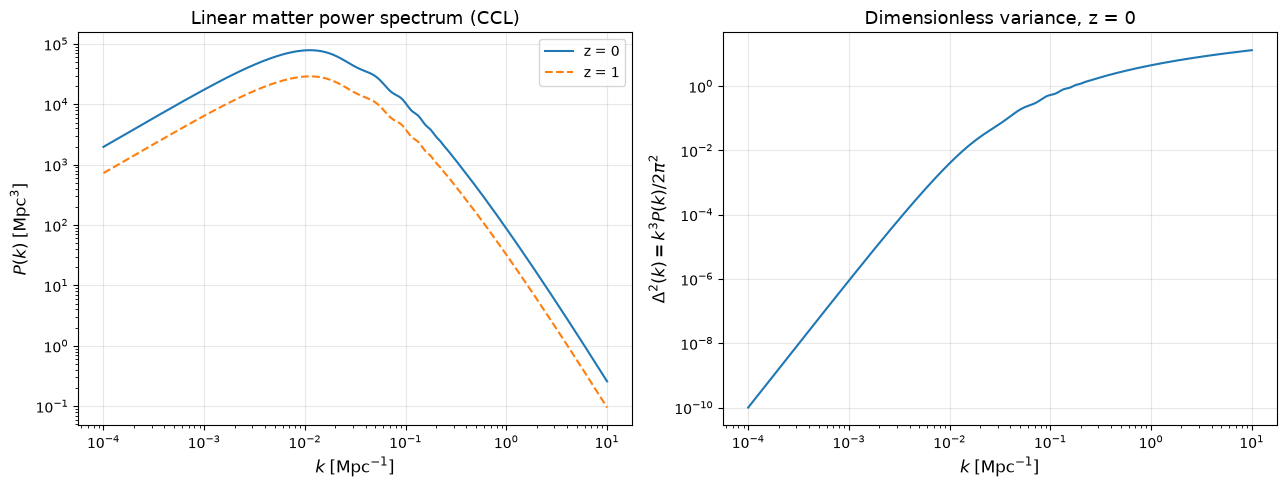

In [2]:
k = np.logspace(-4, 1, 400)               # wavenumber [1/Mpc]  (CCL uses 1/Mpc, no h)
Pk0 = ccl.linear_matter_power(cosmo, k, 1.0)        # z=0  [Mpc^3]
Pk1 = ccl.linear_matter_power(cosmo, k, 1/(1+1.0))  # z=1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.loglog(k, Pk0, label='z = 0')
ax1.loglog(k, Pk1, '--', label='z = 1')
ax1.set_xlabel(r'$k\;[\mathrm{Mpc}^{-1}]$'); ax1.set_ylabel(r'$P(k)\;[\mathrm{Mpc}^3]$')
ax1.set_title('Linear matter power spectrum (CCL)'); ax1.legend()

D2 = k**3 * Pk0 / (2*np.pi**2)
ax2.loglog(k, D2)
ax2.set_xlabel(r'$k\;[\mathrm{Mpc}^{-1}]$'); ax2.set_ylabel(r'$\Delta^2(k)=k^3P(k)/2\pi^2$')
ax2.set_title('Dimensionless variance, z = 0')
fig.tight_layout()
fig.savefig('linear_power_spectrum.png', dpi=130)
fig.savefig('linear_power_spectrum.pdf')
plt.show()


## 3. Cross-check with CAMB — and the $h$-unit trap

CAMB returns $k$ in $h\,\mathrm{Mpc}^{-1}$ and $P(k)$ in $(\mathrm{Mpc}/h)^3$, whereas CCL uses
$\mathrm{Mpc}^{-1}$ and $\mathrm{Mpc}^3$. Converting requires $k=h\,k_h$ and $P = P_h/h^3$. The amplitude
in CAMB is set by the primordial amplitude $A_s$, not by $\sigma_8$, so we rescale by
$(\sigma_8^{\rm target}/\sigma_8^{\rm CAMB})^2$ to compare *shapes* on the same footing
(Lewis, Challinor & Lasenby 2000).


sigma8 from CAMB (As=2.1e-9): 0.8110346799515946


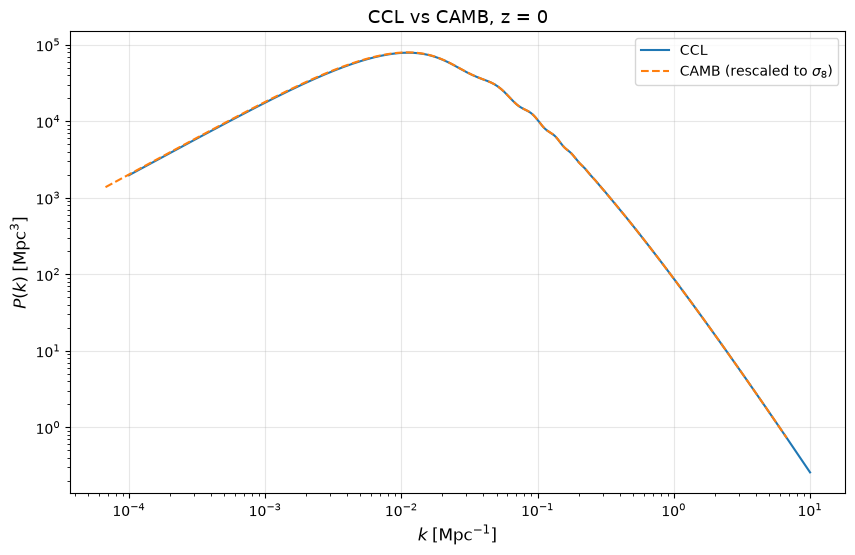

In [3]:
pars = camb.set_params(H0=H0, ombh2=ombh2, omch2=omch2, ns=ns, As=2.1e-9, omk=0.0)
pars.set_matter_power(redshifts=[0.0], kmax=12.0)
pars.NonLinear = camb.model.NonLinear_none
res = camb.get_results(pars)
kh, zc, pk_h = res.get_matter_power_spectrum(minkh=1e-4, maxkh=10.0, npoints=400)
sig8_camb = res.get_sigma8()[-1]
print("sigma8 from CAMB (As=2.1e-9):", sig8_camb)

k_camb = kh * h                       # 1/Mpc
Pk_camb = (pk_h[0] / h**3) * (sig8 / sig8_camb)**2   # Mpc^3, rescaled to target sigma8

plt.figure()
plt.loglog(k, Pk0, label='CCL')
plt.loglog(k_camb, Pk_camb, '--', label='CAMB (rescaled to $\\sigma_8$)')
plt.xlabel(r'$k\;[\mathrm{Mpc}^{-1}]$'); plt.ylabel(r'$P(k)\;[\mathrm{Mpc}^3]$')
plt.title('CCL vs CAMB, z = 0'); plt.legend(); plt.show()


## 4. The growth of structure $D(z)$

In the linear regime each Fourier mode grows with the same scale-independent **growth factor** $D(z)$,
the growing-mode solution of (Peebles 1980, §11; Dodelson & Schmidt 2020, §8.4)

$$\ddot\delta + 2H\dot\delta - 4\pi G\,\bar\rho_m\,\delta = 0.$$

Heath (1977) gives the closed integral form for a $\Lambda$CDM background:

$$D(a) \propto H(a)\int_0^a \frac{da'}{[a'\,H(a')]^3}.$$

A widely used approximation is the Carroll, Press & Turner (1992) fit, in terms of the
density parameters at scale factor $a$:

$$D(a)\propto \frac{5}{2}\,a\,\Omega_m(a)\left[\Omega_m(a)^{4/7}-\Omega_\Lambda(a)
+\Big(1+\tfrac{\Omega_m(a)}{2}\Big)\Big(1+\tfrac{\Omega_\Lambda(a)}{70}\Big)\right]^{-1}.$$


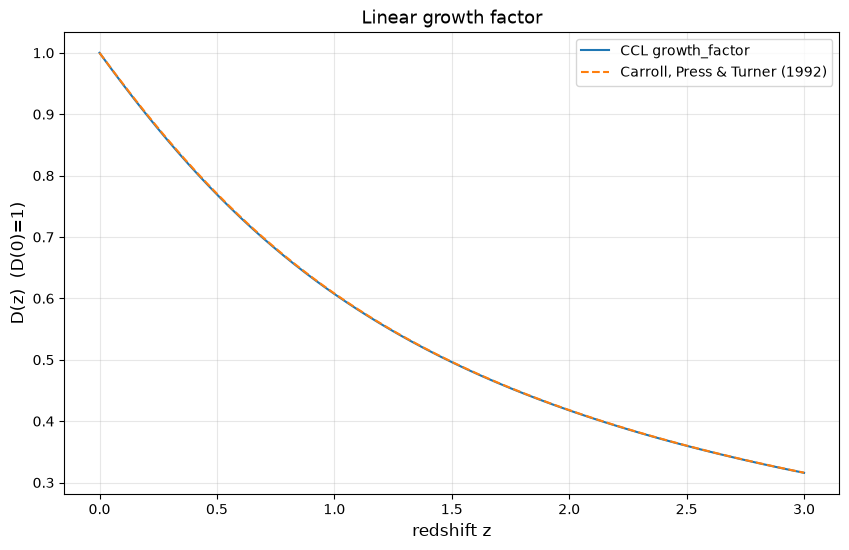

max |D_ccl - D_cpt| = 0.0013753004603331842


In [4]:
z = np.linspace(0, 3, 200)
a = 1.0 / (1 + z)
D_ccl = ccl.growth_factor(cosmo, a)            # normalised to 1 at a=1

# Carroll, Press & Turner (1992) fitting formula, normalised to 1 at z=0
def g_cpt(a):
    Om0, OL0 = Omega_m, 1 - Omega_m
    E2 = Om0 * a**-3 + OL0
    Om = Om0 * a**-3 / E2
    OL = OL0 / E2
    return 2.5 * Om / (Om**(4/7) - OL + (1 + Om/2) * (1 + OL/70))

D_cpt = a * g_cpt(a)
D_cpt /= (1.0 * g_cpt(1.0))                     # normalise to 1 at a=1

plt.figure()
plt.plot(z, D_ccl, label='CCL growth_factor')
plt.plot(z, D_cpt, '--', label='Carroll, Press & Turner (1992)')
plt.xlabel('redshift z'); plt.ylabel('D(z)  (D(0)=1)')
plt.title('Linear growth factor'); plt.legend()
plt.show()
print("max |D_ccl - D_cpt| =", np.max(np.abs(D_ccl - D_cpt)))


## 5. From $P(k)$ to $\sigma_8$

The variance of the linear field smoothed with a real-space top-hat of radius $R$ is
(Peebles 1980, §26):

$$\sigma^2(R) = \int_0^\infty \Delta^2(k)\,|W(kR)|^2\,\frac{dk}{k},
\qquad W(x) = \frac{3\,(\sin x - x\cos x)}{x^3}.$$

The standard amplitude measure is $\sigma_8 \equiv \sigma(R = 8\,h^{-1}\,\mathrm{Mpc})$. We compute it
directly from our $P(k)$ and check it against CCL.


sigma8 from the integral : 0.8111
sigma8 from CCL          : 0.8111
sigma8 input             : 0.8111


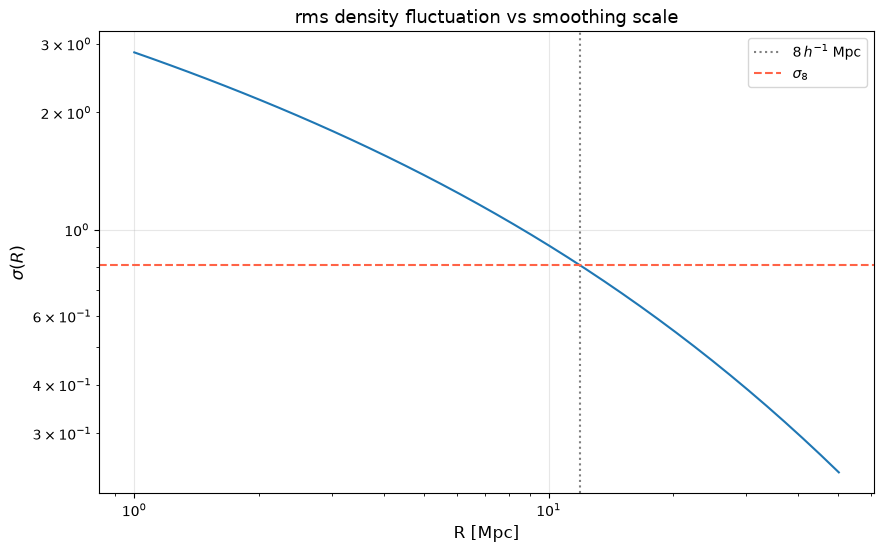

In [5]:
def sigma_R(R, cosmo, a=1.0, kmin=1e-4, kmax=200.0, n=4000):
    # Top-hat variance sigma(R); R in Mpc.
    kk = np.logspace(np.log10(kmin), np.log10(kmax), n)
    Pk = ccl.linear_matter_power(cosmo, kk, a)
    x = kk * R
    W = 3 * (np.sin(x) - x * np.cos(x)) / x**3
    integrand = kk**3 * Pk * W**2 / (2 * np.pi**2)
    return np.sqrt(np.trapezoid(integrand, np.log(kk)))

R8 = 8.0 / h                       # 8 h^-1 Mpc expressed in Mpc
s8_integral = sigma_R(R8, cosmo)
print(f"sigma8 from the integral : {s8_integral:.4f}")
print(f"sigma8 from CCL          : {ccl.sigma8(cosmo):.4f}")
print(f"sigma8 input             : {sig8:.4f}")

# sigma(R) as a function of scale
Rs = np.logspace(0, 1.7, 40)       # Mpc
sR = np.array([sigma_R(R, cosmo) for R in Rs])
plt.figure()
plt.loglog(Rs, sR)
plt.axvline(R8, color='grey', ls=':', label=r'$8\,h^{-1}$ Mpc')
plt.axhline(sig8, color='tomato', ls='--', label=r'$\sigma_8$')
plt.xlabel('R [Mpc]'); plt.ylabel(r'$\sigma(R)$'); plt.legend()
plt.title('rms density fluctuation vs smoothing scale'); plt.show()


## 6. How $\Omega_m$ and $\sigma_8$ shape $P(k)$

These are the two parameters the thesis ultimately constrains. Their effects on the linear spectrum
are nearly orthogonal:

- **$\sigma_8$** is an overall **amplitude** — it scales $P(k)$ up or down at all $k$.
- **$\Omega_m$** (through $\Omega_m h^2$) sets the **turnover scale** $k_{\rm eq}$ and hence the
  *shape*: more matter $\Rightarrow$ earlier equality $\Rightarrow$ turnover at higher $k$
  (BBKS 1986; Eisenstein & Hu 1998).


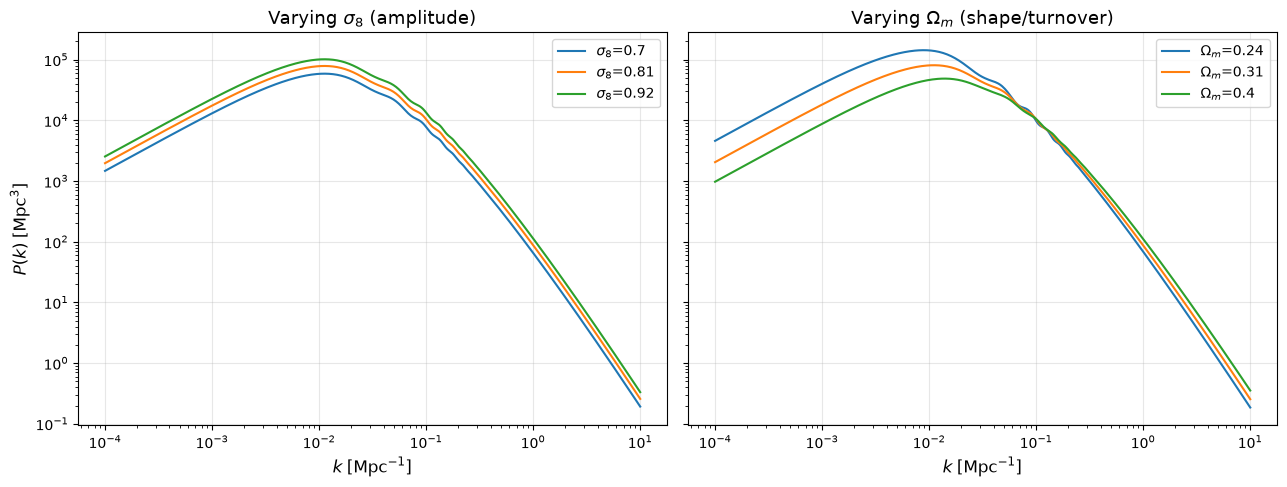

In [6]:
fig, (axa, axb) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for s8 in [0.70, 0.81, 0.92]:
    c = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, h=h, n_s=ns, sigma8=s8)
    axa.loglog(k, ccl.linear_matter_power(c, k, 1.0), label=f'$\\sigma_8$={s8}')
axa.set_title(r'Varying $\sigma_8$ (amplitude)'); axa.legend()
axa.set_xlabel(r'$k\;[\mathrm{Mpc}^{-1}]$'); axa.set_ylabel(r'$P(k)\;[\mathrm{Mpc}^3]$')

for Om in [0.24, 0.31, 0.40]:
    Oc = Om - Omega_b
    c = ccl.Cosmology(Omega_c=Oc, Omega_b=Omega_b, h=h, n_s=ns, sigma8=sig8)
    axb.loglog(k, ccl.linear_matter_power(c, k, 1.0), label=f'$\\Omega_m$={Om}')
axb.set_title(r'Varying $\Omega_m$ (shape/turnover)'); axb.legend()
axb.set_xlabel(r'$k\;[\mathrm{Mpc}^{-1}]$')
fig.tight_layout(); fig.savefig('pk_Om_s8_dependence.png', dpi=130); plt.show()


## 7. Differentiable cosmology with JAX: response functions

Sections 1–6 used CAMB and CCL as black boxes. The thesis instead needs the *derivatives* of
observables with respect to parameters — for Fisher forecasts (N12) and gradient-based inference
(N13). We reimplement $P(k)$ in **JAX** with the BBKS (1986) transfer function and shape parameter
$\Gamma=\Omega_m h$ (Sugiyama 1995), normalised to $\sigma_8$, and let automatic differentiation
return the exact **response functions** $d\ln P(k)/d\ln\theta$.

These responses turn the qualitative amplitude/shape split of Section 6 into a quantitative,
machine-precision statement:

- $d\ln P/d\ln\sigma_8 = 2$ at *every* $k$ — a pure amplitude,
- $d\ln P/d\ln\Omega_m$ is **scale-dependent** — it moves the turnover.

This is the key idea the thesis exploits: the gradient *is* the physical sensitivity.


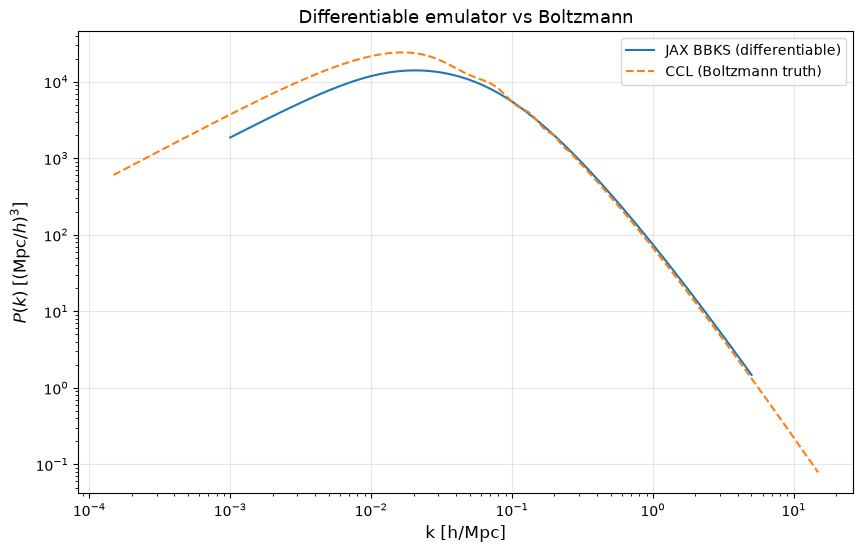

In [7]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

kgrid_norm = jnp.logspace(-3.0, 1.2, 512)        # h/Mpc, for the sigma8 integral

def T_bbks(kk, Gamma):
    # BBKS (1986) transfer function with shape parameter Gamma = Omega_m h (Sugiyama 1995)
    q = kk / Gamma
    L = jnp.log(1.0 + 2.34*q) / (2.34*q)
    poly = 1.0 + 3.89*q + (16.1*q)**2 + (5.46*q)**3 + (6.71*q)**4
    return L * poly**(-0.25)

def shape_pk(kk, Om):
    return kk**ns * T_bbks(kk, Om*h)**2

def sigma8_raw(Om):
    R = 8.0; x = kgrid_norm * R
    W = 3.0*(jnp.sin(x) - x*jnp.cos(x))/x**3
    d2 = kgrid_norm**3 * shape_pk(kgrid_norm, Om) / (2*jnp.pi**2)
    return jnp.sqrt(jnp.trapezoid(d2 * W**2, jnp.log(kgrid_norm)))

def logPk(lnk, Om, s8):
    return jnp.log((s8 / sigma8_raw(Om))**2 * shape_pk(jnp.exp(lnk), Om))

# Cross-check the differentiable BBKS emulator against the CCL Boltzmann result (both at sigma8)
k_h = np.logspace(-3, 0.7, 200)                  # h/Mpc
Pk_jax = np.array(jnp.exp(jax.vmap(lambda lk: logPk(lk, Omega_m, sig8))(jnp.log(k_h))))
plt.figure()
plt.loglog(k_h, Pk_jax, label='JAX BBKS (differentiable)')
plt.loglog(k/h, ccl.linear_matter_power(cosmo, k, 1.0)*h**3, '--', label='CCL (Boltzmann truth)')
plt.xlabel('k [h/Mpc]'); plt.ylabel(r'$P(k)\;[(\mathrm{Mpc}/h)^3]$'); plt.legend()
plt.title('Differentiable emulator vs Boltzmann'); plt.show()


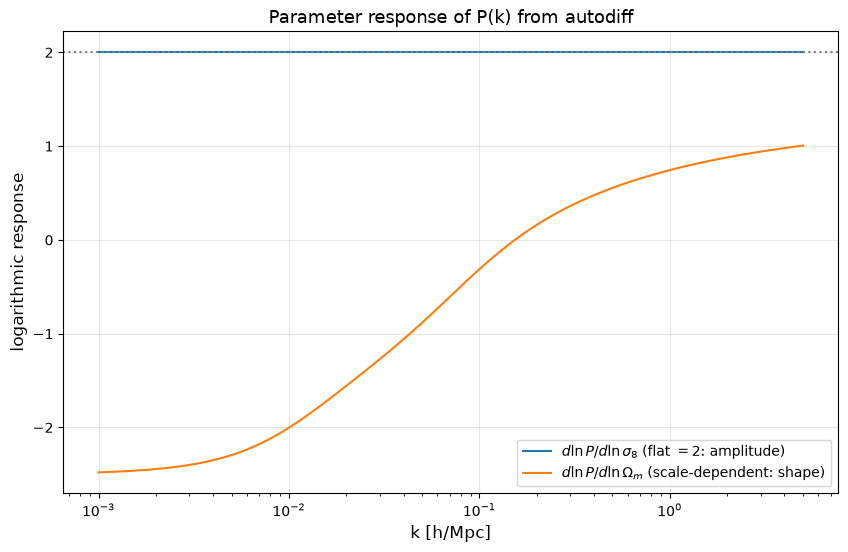

mean d ln P/d ln sigma8 = 2.0 (expected 2)


In [8]:
# Response functions via automatic differentiation
g_Om = jax.vmap(lambda lk: jax.grad(logPk, argnums=1)(lk, Omega_m, sig8))(jnp.log(k_h))
g_s8 = jax.vmap(lambda lk: jax.grad(logPk, argnums=2)(lk, Omega_m, sig8))(jnp.log(k_h))
resp_Om = np.array(Omega_m * g_Om)               # d ln P / d ln Omega_m
resp_s8 = np.array(sig8 * g_s8)                  # d ln P / d ln sigma8

plt.figure()
plt.semilogx(k_h, resp_s8, label=r'$d\ln P/d\ln\sigma_8$ (flat $=2$: amplitude)')
plt.semilogx(k_h, resp_Om, label=r'$d\ln P/d\ln\Omega_m$ (scale-dependent: shape)')
plt.axhline(2.0, color='grey', ls=':')
plt.xlabel('k [h/Mpc]'); plt.ylabel('logarithmic response'); plt.legend()
plt.title('Parameter response of P(k) from autodiff')
plt.savefig('pk_response_autodiff.png', dpi=130); plt.show()
print("mean d ln P/d ln sigma8 =", resp_s8.mean(), "(expected 2)")


## Exercises

1. **Equality scale.** The comoving horizon at matter–radiation equality gives
   $k_{\rm eq}\simeq 0.073\,\Omega_m h^2\;\mathrm{Mpc}^{-1}$ (Eisenstein & Hu 1998, eq. 1).
   Compute $k_{\rm eq}$ for the fiducial cosmology and mark it on the $P(k)$ plot. Does it coincide
   with the turnover?
2. **BAO.** Overlay the *no-wiggle* Eisenstein & Hu (1998) transfer function (CCL
   `transfer_function='eisenstein_hu_nowiggles'`) on the full one and isolate the baryon acoustic
   oscillations as the ratio $P_{\rm full}/P_{\rm nowiggle}$.
3. **Growth and $\Omega_m$.** Recompute $D(z)$ for $\Omega_m\in\{0.2,0.3,0.4\}$. At which redshift do
   the curves differ most, and why does a higher $\Omega_m$ give *more* growth at late times?
4. **$\sigma_8$ vs $S_8$.** Many lensing analyses report $S_8=\sigma_8\sqrt{\Omega_m/0.3}$
   (e.g. Planck Coll. VI 2020). Compute $S_8$ for the fiducial cosmology and explain why lensing
   constrains this particular combination (you will see it again in N09 and N12).
5. **Normalisation.** Verify numerically that scaling $\sigma_8\to 2\sigma_8$ multiplies $P(k)$ by 4 at
   every $k$, confirming $P\propto\sigma_8^2$.


## Summary

- The linear field is a Gaussian random field fully described by $P(k)$; its dimensionless form is
  $\Delta^2(k)=k^3P(k)/2\pi^2$.
- $P(k,z)=A\,k^{n_s}T^2(k)\,[D(z)/D(0)]^2$: primordial slope, transfer function, growth.
- $\sigma_8=\sigma(8\,h^{-1}\mathrm{Mpc})$ ties $P(k)$ to a single amplitude number.
- $\sigma_8$ sets the amplitude, $\Omega_m$ the shape — the two numbers the thesis infers.
- A JAX reimplementation gives the **response functions** $d\ln P/d\ln\theta$ by autodiff:
  $\sigma_8$ is a flat factor of 2, $\Omega_m$ is scale-dependent. The gradient *is* the sensitivity.

**Next (N08):** turn this $P(k)$ into an actual mock density field and a galaxy map — the first step
of the forward model.
